In [1]:
# allow to sync with local code
%load_ext autoreload
%autoreload 2

In [2]:
EXPERIMENT_IDS_FULL = {
    "CIFAR_10": "398072040094588659",
    "CIFAR_10 - 10%": "467724091235265108",
    "Pascal_VOC": "563216254920969354",
    "Pascal_VOC - 10%": "570207184802051099",
    "Imdb": "401871667924599083",
    "Imdb - 10%": "298372821182901995",

}
METRICS = ("test_auroc", "test_acc", "test_iou", "test_micro_iou")

In [3]:
from mlflow import MlflowClient
client = MlflowClient(
    tracking_uri="/home/yann/Documents/YCH-perso/goldener/mlflow/mlruns/"
)

def get_metric_for_experiment(experiment_id, metric_names, name_filters = ["gold"]):
    """
    Get run name and specific metric value for all runs in an experiment.
    """
    runs = client.search_runs(experiment_ids=[experiment_id])

    run_data = []
    for run in runs:
        run_name = run.info.run_name
        if name_filters is not None:
            if any(name_filter in run_name for name_filter in name_filters):
                continue
        split_random_state = run.data.params.get("random_split_state")
        run_info = {"run_name": run_name, "seed": split_random_state}
        metrics_info ={}
        for metric_name in metric_names:
            metric_value = run.data.metrics.get(metric_name, None)
            if metric_value is not None:
                metrics_info[metric_name] = metric_value
        if metrics_info:
            run_data.append(run_info | metrics_info)

    return run_data

get_metric_for_experiment(EXPERIMENT_IDS_FULL["CIFAR_10"], METRICS)


/home/yann/gold-splitter-examples/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yann/gold-splitter-examples/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


[{'run_name': 'cifar10_random_resnet_86',
  'seed': '86',
  'test_auroc': 0.9980476498603821,
  'test_acc': 0.9495999813079834},
 {'run_name': 'cifar10_random_resnet_75',
  'seed': '75',
  'test_auroc': 0.9978986978530884,
  'test_acc': 0.9427000284194946},
 {'run_name': 'cifar10_random_resnet_64',
  'seed': '64',
  'test_auroc': 0.9979246258735657,
  'test_acc': 0.9466999769210815},
 {'run_name': 'cifar10_random_resnet_53',
  'seed': '53',
  'test_auroc': 0.9978421330451965,
  'test_acc': 0.9437000155448914},
 {'run_name': 'cifar10_random_resnet_42',
  'seed': '42',
  'test_auroc': 0.997887134552002,
  'test_acc': 0.9430999755859375}]

In [4]:
# --- Collect all data for all datasets ---
all_data = {}
for dataset_name, experiment_id in EXPERIMENT_IDS_FULL.items():
    all_data[dataset_name] = get_metric_for_experiment(experiment_id, METRICS)

all_data


{'CIFAR_10': [{'run_name': 'cifar10_random_resnet_86',
   'seed': '86',
   'test_auroc': 0.9980476498603821,
   'test_acc': 0.9495999813079834},
  {'run_name': 'cifar10_random_resnet_75',
   'seed': '75',
   'test_auroc': 0.9978986978530884,
   'test_acc': 0.9427000284194946},
  {'run_name': 'cifar10_random_resnet_64',
   'seed': '64',
   'test_auroc': 0.9979246258735657,
   'test_acc': 0.9466999769210815},
  {'run_name': 'cifar10_random_resnet_53',
   'seed': '53',
   'test_auroc': 0.9978421330451965,
   'test_acc': 0.9437000155448914},
  {'run_name': 'cifar10_random_resnet_42',
   'seed': '42',
   'test_auroc': 0.997887134552002,
   'test_acc': 0.9430999755859375}],
 'CIFAR_10 - 10%': [{'run_name': 'cifar10_random_resnet_86',
   'seed': '86',
   'test_auroc': 0.9903751611709595,
   'test_acc': 0.8759999871253967},
  {'run_name': 'cifar10_random_resnet_75',
   'seed': '75',
   'test_auroc': 0.9902524948120117,
   'test_acc': 0.8733000159263611},
  {'run_name': 'cifar10_random_resnet_6

In [5]:
import pandas as pd

# --- Convert to flat DataFrame ---
rows = []
for dataset_name, runs in all_data.items():
    for run in runs:
        for metric in METRICS:
            if metric in run:
                rows.append({
                    "dataset": dataset_name,
                    "run_name": run["run_name"],
                    "seed": str(run["seed"]),  # str for categorical hue
                    "metric": metric,
                    "value": run[metric],
                })

df = pd.DataFrame(rows)
df.head()


,dataset,run_name,seed,metric,value
0,CIFAR_10,cifar10_random_resnet_86,86,test_auroc,0.998048
1,CIFAR_10,cifar10_random_resnet_86,86,test_acc,0.949600
2,CIFAR_10,cifar10_random_resnet_75,75,test_auroc,0.997899
3,CIFAR_10,cifar10_random_resnet_75,75,test_acc,0.942700
4,CIFAR_10,cifar10_random_resnet_64,64,test_auroc,0.997925


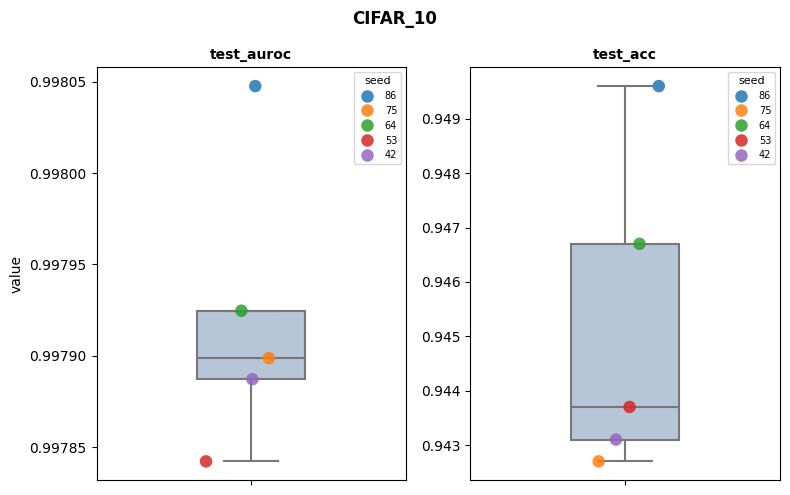

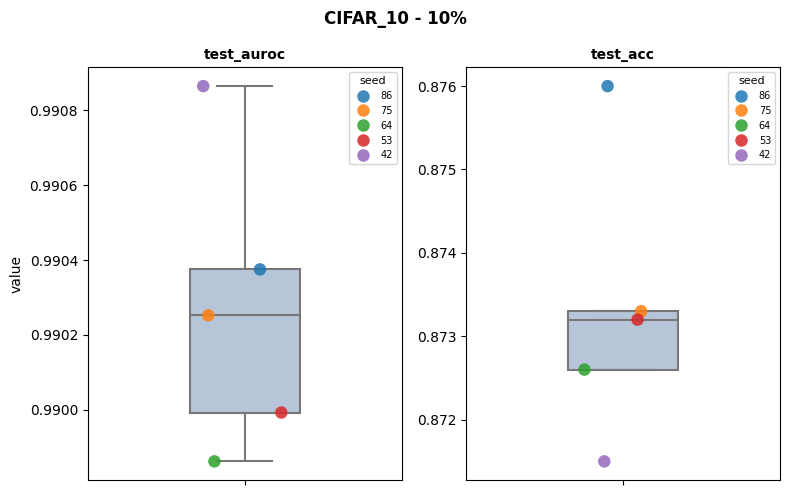

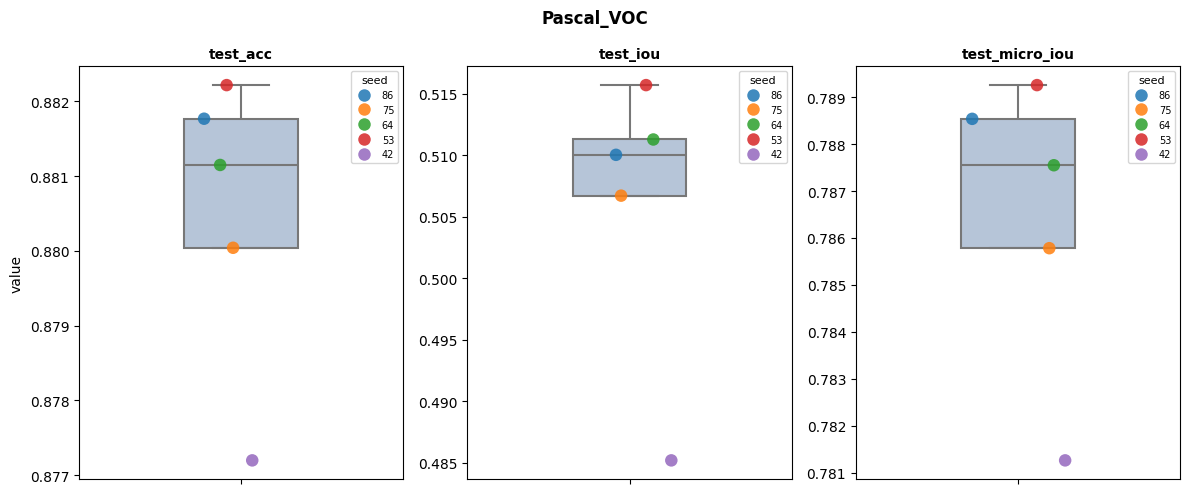

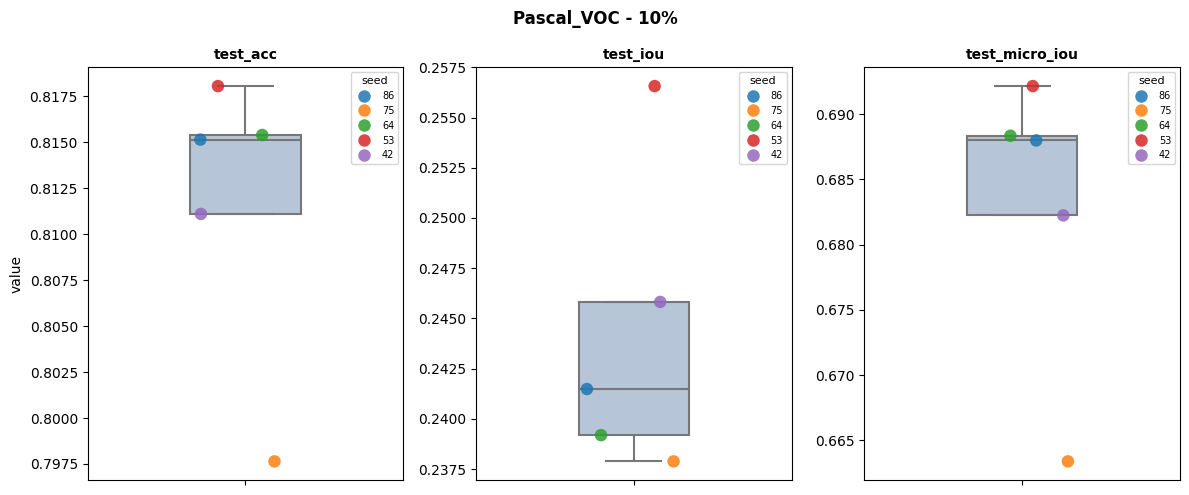

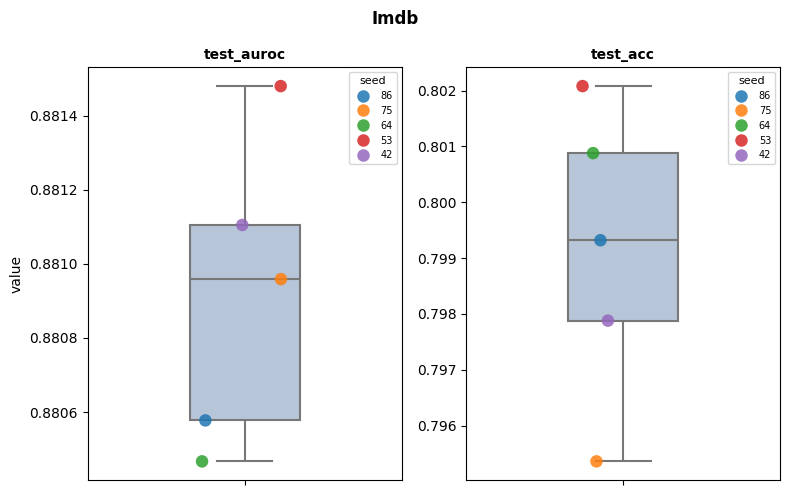

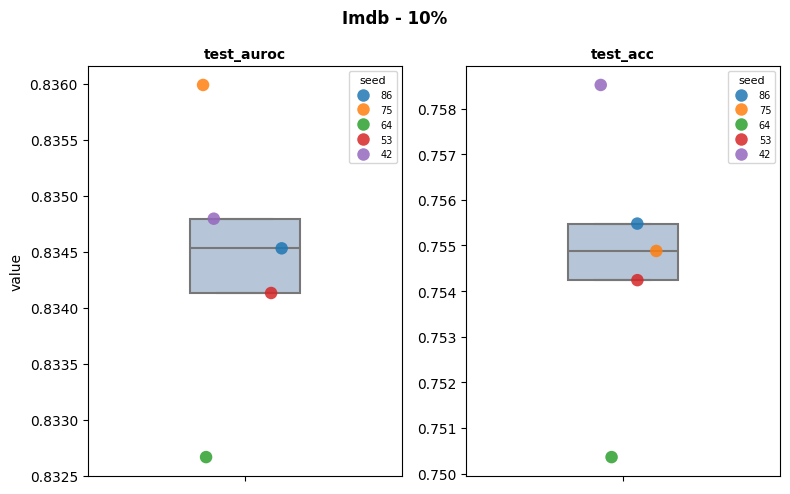

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


for dataset in EXPERIMENT_IDS_FULL.keys():
    dataset_df = df[df["dataset"] == dataset]
    dataset_metrics = [m for m in METRICS if m in dataset_df["metric"].values]

    if not dataset_metrics:
        continue

    fig, axes = plt.subplots(
        1, len(dataset_metrics),
        figsize=(4 * len(dataset_metrics), 5),
        squeeze=False,
    )

    for j, metric in enumerate(dataset_metrics):
        ax = axes[0][j]
        subset = dataset_df[dataset_df["metric"] == metric]

        # Box plot: shows median, IQR and overall dispersion
        sns.boxplot(
            data=subset, y="value", ax=ax,
            color="lightsteelblue", width=0.35,
            fliersize=0, linewidth=1.5,
        )
        # Strip plot: one dot per seed, each seed has a distinct colour
        sns.stripplot(
            data=subset, y="value", hue="seed", ax=ax,
            size=9, jitter=0.15, alpha=0.85, palette="tab10",
        )

        ax.set_title(metric, fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("value" if j == 0 else "")
        ax.legend(title="seed", fontsize=7, title_fontsize=8, loc="best")

    fig.suptitle(f"{dataset}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


In [11]:
metrics_present = [m for m in METRICS if m in df["metric"].values]

summary = (
    df.groupby(["dataset", "metric"])["value"]
    .agg(min="min", max="max")
    .round(4)
)

# Build one row per dataset with "min / max" string per metric
table_rows = []
for dataset in EXPERIMENT_IDS_FULL.keys():
    row = {"Dataset": dataset}
    for metric in metrics_present:
        try:
            mn = summary.loc[(dataset, metric), "min"]
            mx = summary.loc[(dataset, metric), "max"]
            row[metric] = f"{mn} / {mx}"
        except KeyError:
            row[metric] = "-"
    table_rows.append(row)

table_df = pd.DataFrame(table_rows).set_index("Dataset")
print(table_df.to_markdown())


| Dataset          | test_auroc      | test_acc        | test_iou        | test_micro_iou   |
|:-----------------|:----------------|:----------------|:----------------|:-----------------|
| CIFAR_10         | 0.9978 / 0.998  | 0.9427 / 0.9496 | -               | -                |
| CIFAR_10 - 10%   | 0.9899 / 0.9909 | 0.8715 / 0.876  | -               | -                |
| Pascal_VOC       | -               | 0.8772 / 0.8822 | 0.4852 / 0.5157 | 0.7813 / 0.7893  |
| Pascal_VOC - 10% | -               | 0.7976 / 0.8181 | 0.2379 / 0.2566 | 0.6634 / 0.6921  |
| Imdb             | 0.8805 / 0.8815 | 0.7954 / 0.8021 | -               | -                |
| Imdb - 10%       | 0.8327 / 0.836  | 0.7504 / 0.7585 | -               | -                |
